## ЛР 3

In [190]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from typing import Tuple

# 3 вариант
M1 = np.array([0.0, 0.0])
M2 = np.array([-1.0, 1.0])
M3 = np.array([-1.0, -1.0])

B1 = np.array([[0.2, -0.1],
               [-0.1, 0.4]])

B2 = np.array([[0.4, -0.2],
               [-0.2, 0.4]])

B3 = np.array([[0.3, -0.05],
               [-0.05, 0.3]])

N = 200

Генерация нормальных векторов

In [191]:
def get_normal_vector(M: np.ndarray, B: np.ndarray) -> np.ndarray:
    """Исправленная версия вашего метода"""
    A = np.zeros((2, 2))
    A[0, 0] = np.sqrt(B[0, 0])
    A[1, 0] = B[0, 1] / A[0, 0]
    A[1, 1] = np.sqrt(B[1, 1] - np.power(A[1, 0], 2))
    
    def approx_norm():
        U = np.random.uniform(0, 1, 30)
        return (np.sum(U) - 30/2) / np.sqrt(30/12)
    
    E = np.array([approx_norm(), approx_norm()])
    X = np.dot(A, E) + M.reshape(2)
    
    return X

In [192]:
# Генерация выборок для равных ковариационных матриц
X1_samples1 = np.array([get_normal_vector(M1, B2).flatten() for _ in range(N)])
X2_samples1 = np.array([get_normal_vector(M2, B2).flatten() for _ in range(N)])

# Генерация выборок для неравных ковариационных матриц  
X1_samples2 = np.array([get_normal_vector(M1, B1).flatten() for _ in range(N)])
X2_samples2 = np.array([get_normal_vector(M2, B2).flatten() for _ in range(N)])

Статистические функции

In [193]:
def get_mean(X: np.ndarray, N: int) -> np.ndarray:
    return np.sum(X, axis=0) / N

def get_var(X: np.ndarray, N: int) -> np.ndarray:
    # Выборочная дисперсия
    variances = []
    for row in X.transpose():
        mean = sum(row) / N
        var = sum((x - mean) ** 2 for x in row) / (N - 1)
        variances.append(var)
    return np.array(variances)

def get_cov(X: np.ndarray) -> np.ndarray:
    # Выборочная ковариационная матрица
    X1 = X.transpose()
    num_rows, num_cols = X1.shape
    means = np.array([sum(X1[i]) / num_cols for i in range(num_rows)])
    
    cov_matrix = np.zeros((num_rows, num_rows))
    for i in range(num_rows):
        for j in range(num_rows):
            cov = sum((X1[i, k] - means[i]) * (X1[j, k] - means[j]) for k in range(num_cols)) / (num_cols - 1)
            cov_matrix[i, j] = cov
    return np.array(cov_matrix)

Байесовский классификатор

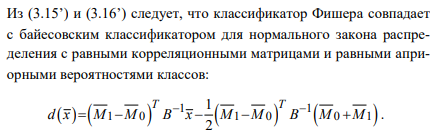

In [194]:
def Bayes_Classificator(M1: np.ndarray, M2: np.ndarray, 
                        B: np.ndarray, min: float, max: float, 
                        prob1: float, prob2: float) -> Tuple[np.ndarray, np.ndarray]:
    """
    Байесовский классификатор для нормальных распределений с равными ковариационными матрицами
    """
    M1 = M1.reshape(1, 2)[0]
    M2 = M2.reshape(1, 2)[0]

    x = np.linspace(min, max, 200)
    B_inv = np.linalg.inv(B)
    
    a = np.dot((M1 - M2).T, B_inv)
    b = -0.5 * np.dot(np.dot((M1 + M2).T, B_inv), (M1 - M2)) + np.log(prob1 / prob2)
    
    y = (-a[0] * x - b) / a[1]
    return x, y

Кретерий Фишера

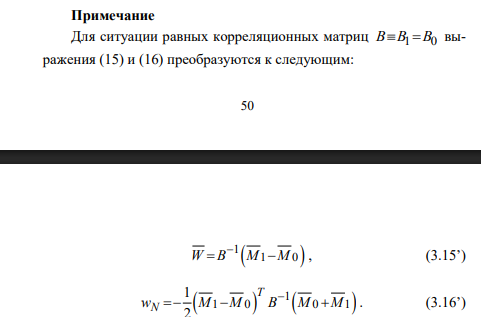

In [195]:
def criterion_Fisher(min_X1_X2, max_X1_X2, M0, M1, B0, B1):
    """
    Классификатор Фишера - максимизация критерия (m1 - m0)^2 / (σ1^2 + σ0^2)
    """
    M1 = M1.reshape(1, 2)[0]
    M0 = M0.reshape(1, 2)[0]

    def get_W(M0, M1, B0, B1):
        return np.dot(np.linalg.inv(0.5 * (B0 + B1)), (M1 - M0))

    def get_STD2(W, B):
        return np.dot(np.dot(W.T, B), W)
    
    def get_Wn(M0, M1, B0, B1):
        W = get_W(M0, M1, B0, B1)
        std2_0 = get_STD2(W, B0)
        std2_1 = get_STD2(W, B1)

        coef1 = -1 / (std2_0 + std2_1) * np.transpose(M1 - M0)
        coef2 = np.linalg.inv(0.5 * (B0 + B1))
        coef3 = std2_1 * M0 + std2_0 * M1

        return W, np.dot(np.dot(coef1, coef2), coef3), std2_0, std2_1
    
    W, Wn, _, _ = get_Wn(M0, M1, B0, B1)
    x = np.linspace(min_X1_X2, max_X1_X2, 200)
    y = (-W[0] * x - Wn) / W[1]
    return x, y

Классификатор минимального СКО

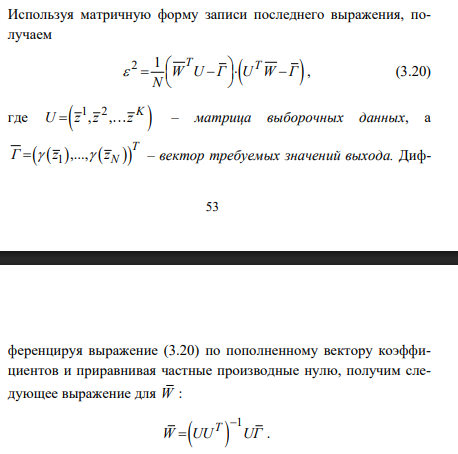

In [196]:
def criterion_Min_STD(X1, X2, min_X, max_X):
    U = np.zeros((3, 400))
    U[2, 200:] = 1
    U[2, :200] = -1
    U[:2, 200:] = np.copy(X1.T)
    U[:2, :200] = -np.copy(X2.T)

    G = np.ones(400)

    W = np.dot(np.dot(np.linalg.inv(np.dot(U, U.T)), U), G) 

    x = np.linspace(min_X, max_X, 200)
    y = (-W[0] * x - W[2]) / W[1]
    return x, y

Процедура Роббинса-Монро

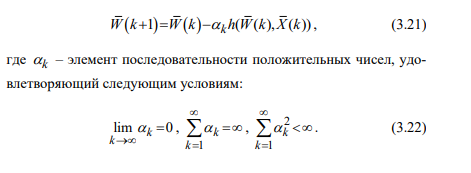

In [197]:
def cos_similarity(x: np.ndarray, y: np.ndarray) -> float:
    """Вычисление косинусного сходства между векторами"""
    dot_product = np.dot(x, y)
    norm_x = np.linalg.norm(x)
    norm_y = np.linalg.norm(y)
    
    if norm_x == 0 or norm_y == 0:
        return 0.0
    
    return float(dot_product / (norm_x * norm_y))

def Robinson_Monroe(X1, X2, min_X, max_X, beta, W, epsilon=1e-5, plot=False):
    """
    Процедура Роббинса-Монро для последовательной корректировки классификатора
    Соответствует формуле (3.21): W(k+1) = W(k) - α_k * h(W(k), X(k))
    """
    # ОБРЕЗАЕМ размерность до 2 признаков
    X1 = X1[:, :2]  # берем только первые 2 признака
    X2 = X2[:, :2]  # берем только первые 2 признака
    
    n1 = X1.shape[0]
    n2 = X2.shape[0]
    total_samples = n1 + n2
    
    # Подготовка данных
    X = np.zeros((4, total_samples))
    X[2, :] = 1  # столбец единиц для смещения
    X[3, n1:] = 1  # класс 1
    X[3, :n1] = -1  # класс 0
    
    # Заполняем признаки
    X[0, :n1] = X1[:, 0]  # x-координаты класса 0
    X[1, :n1] = X1[:, 1]  # y-координаты класса 0
    X[0, n1:] = X2[:, 0]  # x-координаты класса 1  
    X[1, n1:] = X2[:, 1]  # y-координаты класса 1

    # Перемешиваем данные
    X = np.transpose(X)
    np.random.shuffle(X)
    X = np.transpose(X)
    
    prev = np.array(W, dtype=float)
    counter = 1
    epoch = 1
    
    if plot:
        plt.figure(figsize=(12, 8))
        plt.scatter(X1[:,0], X1[:,1], s=15, label='X1', alpha=0.8, color="blue")
        plt.scatter(X2[:,0], X2[:,1], s=15, label='X2', alpha=0.8, color="orange")

    Wepoch = prev.copy()
    
    while True:
        if epoch != 1:
            Wepoch = Wi.copy()
            
        for i in range(total_samples):
            alpha = 1 / (counter ** beta)
            # Формула коррекции (3.21)
            Wi = prev + alpha * X[:3, i] * np.sign(X[3][i] - np.dot(prev, X[:3, i]))
            prev = Wi.copy()
            counter += 1

        if plot and (epoch <= 5 or epoch % 10 == 0):
            print(f"Epoch {epoch}")
            x0 = np.linspace(min_X, max_X, 100)
            x1 = (-Wi[0] * x0 - Wi[2]) / Wi[1]
            plt.plot(x0, x1, label=f"epoch {epoch}")

        # Проверка сходимости
        if cos_similarity(Wepoch[:2], Wi[:2]) > 1 - epsilon: 
            if plot: 
                print(f"Сходимость достигнута на эпохе {epoch}")
            break
        
        epoch += 1
        if epoch > 1000:  # ограничение на максимальное число эпох
            if plot:
                print(f"Достигнуто максимальное число эпох: {epoch}")
            break

    if plot:
        plt.legend()
        plt.title(f"Процедура Роббинса-Монро (β={beta})")
        plt.xlabel('Координата X')
        plt.ylabel('Координата Y')
        plt.grid(True)
        plt.show()

    x = np.linspace(min_X, max_X, 200)
    y = (-Wi[0] * x - Wi[2]) / Wi[1]

    return x, y, epoch

Вспомогательные функции

In [198]:
def fit_line_from_points(x: np.ndarray, y: np.ndarray, degree=1):
    """Аппроксимация разделяющей границы полиномом"""
    if degree == 1:
        a, b = np.polyfit(x, y, deg=degree)
        eq = f'y = {a:.6f} * x + {b:.6f}'
        return float(a), float(b), eq
    elif degree == 2:
        a, b, c = np.polyfit(x, y, deg=degree)
        eq = f'y = {a:.6f} * x^2 + {b:.6f} * x + {c:.6f}'
        return float(a), float(b), float(c), eq

def compute_number_errors2(X1: np.ndarray, X2: np.ndarray, 
                          coef_a: float, coef_b: float) -> Tuple[float, float]:
    """Вычисление экспериментальных вероятностей ошибок для линейной границы"""
    n = X1.shape[0]
    
    count_errors_I = 0
    for vector in X1:
        if coef_a * vector[0] + coef_b > vector[1]:
            count_errors_I += 1
    err_I = float(count_errors_I / n)

    count_errors_II = 0
    for vector in X2:
        if coef_a * vector[0] + coef_b < vector[1]:
            count_errors_II += 1
    err_II = float(count_errors_II / n)      

    return err_I, err_II

def compute_number_errors(X1: np.ndarray, X2: np.ndarray, coef_a: float, coef_b: float, coef_c: float) -> Tuple[float, float]:
    """Вычисление экспериментальных вероятностей ошибок для квадратичной границы"""
    n = X1.shape[0]

    count_errors_I = 0
    for vector in X1:
        if coef_a * vector[0] ** 2 + coef_b * vector[0] + coef_c > vector[1]:
            count_errors_I += 1
    err_I = float(count_errors_I / n)

    count_errors_II = 0
    for vector in X2:
        if coef_a * vector[0] ** 2 + coef_b * vector[0] + coef_c < vector[1]:
            count_errors_II += 1
    err_II = float(count_errors_II / n)

    return err_I, err_II

def get_dist_Mahalanobis(M1: np.ndarray, M2: np.ndarray, B1: np.ndarray, B2 = None) -> np.ndarray:
    """Расстояние Махаланобиса между распределениями"""
    if B2 is None:
        B = B1
    else:
        B = (B1 + B2) / 2
    return np.dot(np.dot((M1 - M2).T, np.linalg.inv(B)), (M1 - M2))

def get_row_for_2_classes_for_x(M1, M2, B1, B2, x):
    """
    Байесовский классификатор для нормальных распределений с неравными ковариационными матрицами
    Из вашего примера
    """
    A = 0.5 * (np.linalg.inv(B2) - np.linalg.inv(B1))
    
    b = np.dot(np.transpose(M1), np.linalg.inv(B1)) - np.dot(np.transpose(M2), np.linalg.inv(B2))
    c = (np.dot(np.dot(0.5 * M2.transpose(), np.linalg.inv(B2)), M2) \
         + np.dot(np.dot(-0.5 * M1.transpose(), np.linalg.inv(B1)), M1)
         + 0.5 * np.log(np.linalg.det(B2) / np.linalg.det(B1)))
    
    coeff_y = (A[1][0] * x + A[0][1] * x + b[0][1]) / A[1][1]
    coeff_c = (A[0][0] * x * x + b[0][0] * x + c[0][0]) / A[1][1]

    D = np.power(coeff_y, 2) - 4 * 1 * coeff_c

    y1 = (- coeff_y[D >= 0] + np.sqrt(D[D >= 0])) / 2
    y2 = (- coeff_y[D >= 0] - np.sqrt(D[D >= 0])) / 2

    return x[D > 0], y1, y2

def compute_number_errors(X1: np.ndarray, X2: np.ndarray, coef_a: float, coef_b: float, coef_c: float) -> Tuple[float, float]:
    """Вычисление экспериментальных вероятностей ошибок для квадратичной границы"""
    n = X1.shape[0]

    count_errors_I = 0
    for vector in X1:
        if coef_a * vector[0] ** 2 + coef_b * vector[0] + coef_c > vector[1]:
            count_errors_I += 1
    err_I = float(count_errors_I / n)

    count_errors_II = 0
    for vector in X2:
        if coef_a * vector[0] ** 2 + coef_b * vector[0] + coef_c < vector[1]:
            count_errors_II += 1
    err_II = float(count_errors_II / n)

    return err_I, err_II

Эксперименты с равными ковариационными матрицами

Построение классификаторов для равных ковариационных матриц...
Классификатор Фишера построен
Байесовский классификатор построен
Классификатор мин. СКО построен


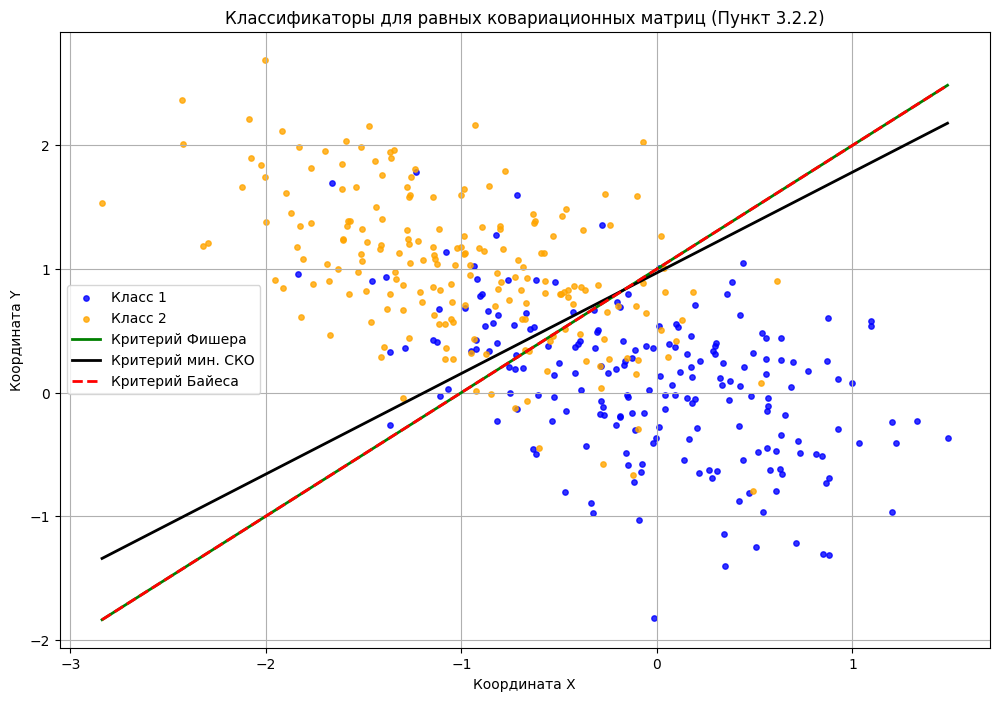


=== РАВНЫЕ КОВАРИАЦИОННЫЕ МАТРИЦЫ ===
Байесовский классификатор
Уравнение границы: y = 1.000000 * x + 1.000000
Вероятность ошибки I рода: 0.800
Вероятность ошибки II рода: 0.815
Суммарная ошибка: 1.615

Классификатор Фишера
Уравнение границы: y = 1.000000 * x + 1.000000
Вероятность ошибки I рода: 0.800
Вероятность ошибки II рода: 0.815
Суммарная ошибка: 1.615

Классификатор мин. СКО
Уравнение границы: y = 0.814332 * x + 0.968944
Вероятность ошибки I рода: 0.815
Вероятность ошибки II рода: 0.815
Суммарная ошибка: 1.630


In [199]:
# Вычисление диапазонов данных
min_X1_X2_1 = np.min(np.concatenate((X1_samples1[:, 0], X2_samples1[:, 0])))
max_X1_X2_1 = np.max(np.concatenate((X1_samples1[:, 0], X2_samples1[:, 0])))

# Вычисление статистик
meanX1_1 = get_mean(X1_samples1, N)
meanX2_1 = get_mean(X2_samples1, N)
covX1_1 = get_cov(X1_samples1) 
covX2_1 = get_cov(X2_samples1) 

# Построение классификаторов
prob1 = 0.5
prob2 = 1 - prob1

print("Построение классификаторов для равных ковариационных матриц...")

x_Fisher1, y_Fisher1 = criterion_Fisher(min_X1_X2_1, max_X1_X2_1, M1, M2, B2, B2)
print("Классификатор Фишера построен")

x_Bayes1, y_Bayes1 = Bayes_Classificator(M1, M2, B2, min_X1_X2_1, max_X1_X2_1, prob1, prob2)
print("Байесовский классификатор построен")

x_MinSTD1, y_MinSTD1 = criterion_Min_STD(X1_samples1, X2_samples1, min_X1_X2_1, max_X1_X2_1)
print("Классификатор мин. СКО построен")

# Визуализация
plt.figure(figsize=(12,8))
plt.scatter(X1_samples1[:,0], X1_samples1[:,1], s=15, label='Класс 1', alpha=0.8, color='blue')
plt.scatter(X2_samples1[:,0], X2_samples1[:,1], s=15, label='Класс 2', alpha=0.8, color='orange')

plt.plot(x_Fisher1, y_Fisher1, label='Критерий Фишера', color='green', linewidth=2)
plt.plot(x_MinSTD1, y_MinSTD1, label='Критерий мин. СКО', color='black', linewidth=2)
plt.plot(x_Bayes1, y_Bayes1, label='Критерий Байеса', color='red', linestyle='--', linewidth=2)
plt.legend()
plt.xlabel('Координата Х')
plt.ylabel('Координата Y')
plt.title('Классификаторы для равных ковариационных матриц (Пункт 3.2.2)')
plt.grid(True)
plt.show()

# Расчет ошибок классификации
print("\n=== РАВНЫЕ КОВАРИАЦИОННЫЕ МАТРИЦЫ ===")

# Для Байесовского классификатора
a, b, eq = fit_line_from_points(x_Bayes1, y_Bayes1)
p0_Bayes1_exp, p1_Bayes1_exp = compute_number_errors2(X1_samples1, X2_samples1, a, b)
print("Байесовский классификатор")
print(f"Уравнение границы: {eq}")
print(f"Вероятность ошибки I рода: {p0_Bayes1_exp:.3f}")
print(f"Вероятность ошибки II рода: {p1_Bayes1_exp:.3f}")
print(f"Суммарная ошибка: {p0_Bayes1_exp + p1_Bayes1_exp:.3f}")

# Для классификатора Фишера
a, b, eq = fit_line_from_points(x_Fisher1, y_Fisher1)
p0_Fisher1_exp, p1_Fisher1_exp = compute_number_errors2(X1_samples1, X2_samples1, a, b)
print("\nКлассификатор Фишера")
print(f"Уравнение границы: {eq}")
print(f"Вероятность ошибки I рода: {p0_Fisher1_exp:.3f}")
print(f"Вероятность ошибки II рода: {p1_Fisher1_exp:.3f}")
print(f"Суммарная ошибка: {p0_Fisher1_exp + p1_Fisher1_exp:.3f}")

# Для классификатора мин. СКО
a, b, eq = fit_line_from_points(x_MinSTD1, y_MinSTD1)
p0_MinSTD1_exp, p1_MinSTD1_exp = compute_number_errors2(X1_samples1, X2_samples1, a, b)
print("\nКлассификатор мин. СКО")
print(f"Уравнение границы: {eq}")
print(f"Вероятность ошибки I рода: {p0_MinSTD1_exp:.3f}")
print(f"Вероятность ошибки II рода: {p1_MinSTD1_exp:.3f}")
print(f"Суммарная ошибка: {p0_MinSTD1_exp + p1_MinSTD1_exp:.3f}")

Эксперименты с неравными ковариационными матрицами

Построение классификаторов для неравных ковариационных матриц...
Классификатор Фишера построен
Байесовский классификатор построен
Классификатор мин. СКО построен


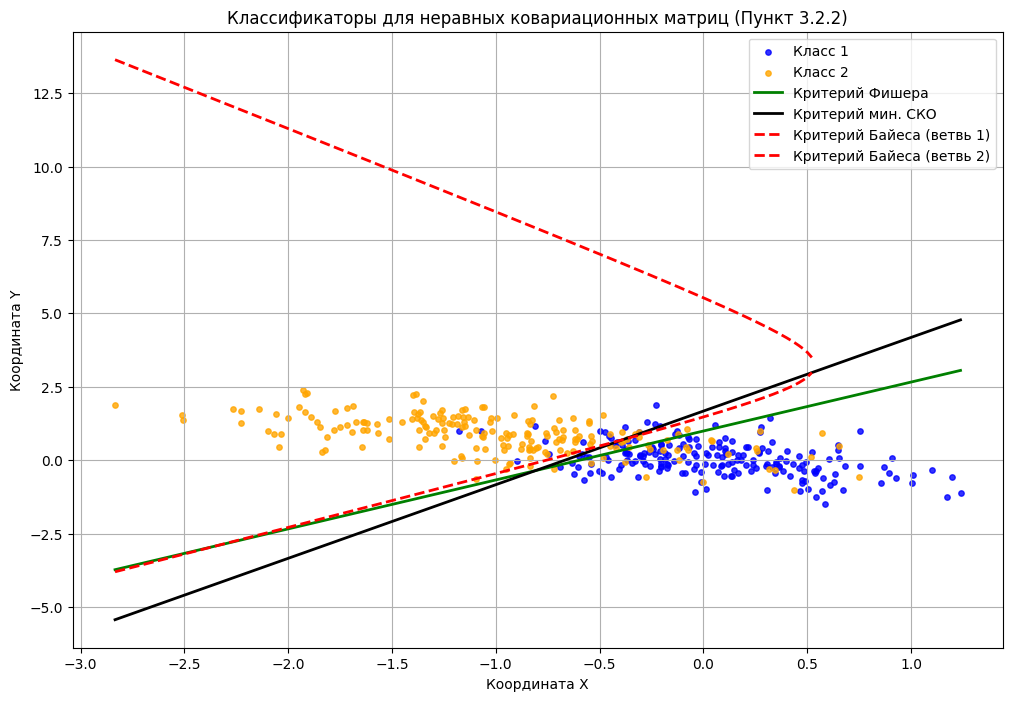


=== НЕРАВНЫЕ КОВАРИАЦИОННЫЕ МАТРИЦЫ ===
Классификатор Фишера
Уравнение границы: y = 1.666667 * x + 0.991453
Вероятность ошибки I рода: 0.845
Вероятность ошибки II рода: 0.865
Суммарная ошибка: 1.710

Классификатор мин. СКО
Уравнение границы: y = 2.507516 * x + 1.670643
Вероятность ошибки I рода: 0.910
Вероятность ошибки II рода: 0.820
Суммарная ошибка: 1.730

Байесовский классификатор (квадратичный)
Для квадратичной границы расчет ошибок требует специальной функции


In [200]:
# Вычисление диапазонов данных для неравных матриц
min_X1_X2_2 = np.min(np.concatenate((X1_samples2[:, 0], X2_samples2[:, 0])))
max_X1_X2_2 = np.max(np.concatenate((X1_samples2[:, 0], X2_samples2[:, 0])))

# Вычисление статистик
meanX1_2 = get_mean(X1_samples2, N)
meanX2_2 = get_mean(X2_samples2, N)

print("Построение классификаторов для неравных ковариационных матриц...")

x_Fisher2, y_Fisher2 = criterion_Fisher(min_X1_X2_2, max_X1_X2_2, M1, M2, B1, B2)
print("Классификатор Фишера построен")

# Для неравных матриц Байесовский классификатор квадратичный
# Используем исходные матрицы B1 и B2 вместо выборочных
x_Bayes2, y_Bayes2_1, y_Bayes2_2 = get_row_for_2_classes_for_x(M1.reshape(-1, 1), M2.reshape(-1, 1), B1, B2, np.linspace(min_X1_X2_2, max_X1_X2_2, 200))
print("Байесовский классификатор построен")

x_MinSTD2, y_MinSTD2 = criterion_Min_STD(X1_samples2, X2_samples2, min_X1_X2_2, max_X1_X2_2)
print("Классификатор мин. СКО построен")

# Визуализация
plt.figure(figsize=(12,8))
plt.scatter(X1_samples2[:,0], X1_samples2[:,1], s=15, label='Класс 1', alpha=0.8, color='blue')
plt.scatter(X2_samples2[:,0], X2_samples2[:,1], s=15, label='Класс 2', alpha=0.8, color='orange')

plt.plot(x_Fisher2, y_Fisher2, label='Критерий Фишера', color='green', linewidth=2)
plt.plot(x_MinSTD2, y_MinSTD2, label='Критерий мин. СКО', color='black', linewidth=2)
plt.plot(x_Bayes2, y_Bayes2_1, label='Критерий Байеса (ветвь 1)', color='red', linestyle='--', linewidth=2)
plt.plot(x_Bayes2, y_Bayes2_2, label='Критерий Байеса (ветвь 2)', color='red', linestyle='--', linewidth=2)
plt.legend()
plt.xlabel('Координата Х')
plt.ylabel('Координата Y')
plt.title('Классификаторы для неравных ковариационных матриц (Пункт 3.2.2)')
plt.grid(True)
plt.show()

# Расчет ошибок классификации
print("\n=== НЕРАВНЫЕ КОВАРИАЦИОННЫЕ МАТРИЦЫ ===")

# Для классификатора Фишера
a, b, eq = fit_line_from_points(x_Fisher2, y_Fisher2)
p0_Fisher2_exp, p1_Fisher2_exp = compute_number_errors2(X1_samples2, X2_samples2, a, b)
print("Классификатор Фишера")
print(f"Уравнение границы: {eq}")
print(f"Вероятность ошибки I рода: {p0_Fisher2_exp:.3f}")
print(f"Вероятность ошибки II рода: {p1_Fisher2_exp:.3f}")
print(f"Суммарная ошибка: {p0_Fisher2_exp + p1_Fisher2_exp:.3f}")

# Для классификатора мин. СКО
a, b, eq = fit_line_from_points(x_MinSTD2, y_MinSTD2)
p0_MinSTD2_exp, p1_MinSTD2_exp = compute_number_errors2(X1_samples2, X2_samples2, a, b)
print("\nКлассификатор мин. СКО")
print(f"Уравнение границы: {eq}")
print(f"Вероятность ошибки I рода: {p0_MinSTD2_exp:.3f}")
print(f"Вероятность ошибки II рода: {p1_MinSTD2_exp:.3f}")
print(f"Суммарная ошибка: {p0_MinSTD2_exp + p1_MinSTD2_exp:.3f}")

# Для Байесовского классификатора (квадратичного)
print("\nБайесовский классификатор (квадратичный)")
print("Для квадратичной границы расчет ошибок требует специальной функции")

Исследование процедуры Роббинса-Монро

=== ПРОЦЕДУРА РОББИНСА-МОНРО ===
Для равных ковариационных матриц:
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Сходимость достигнута на эпохе 8


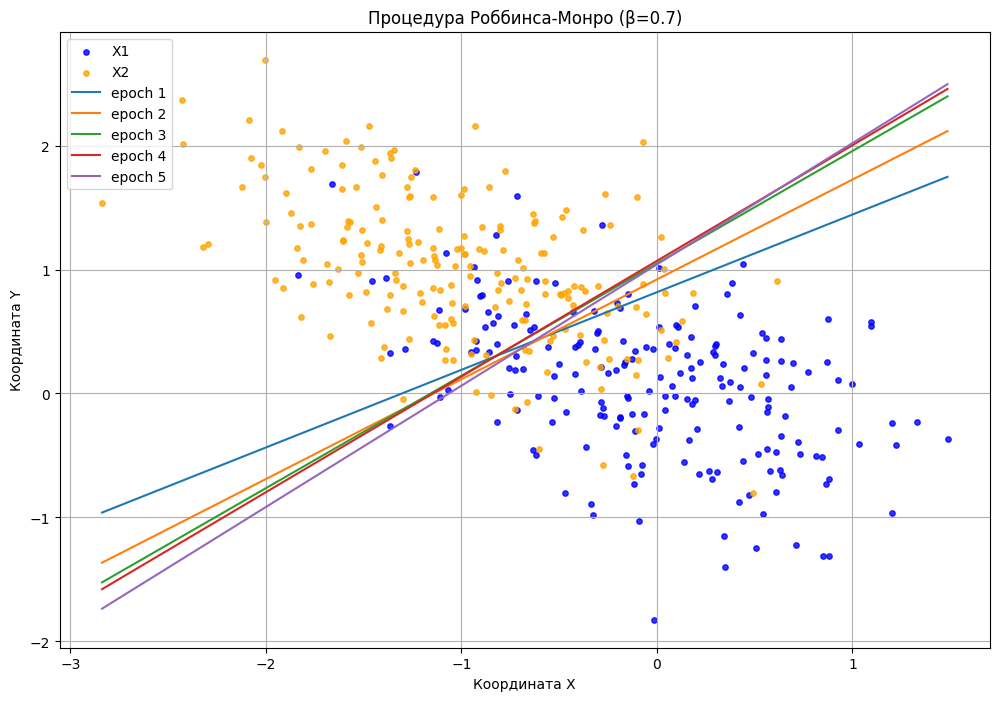


Для неравных ковариационных матриц:


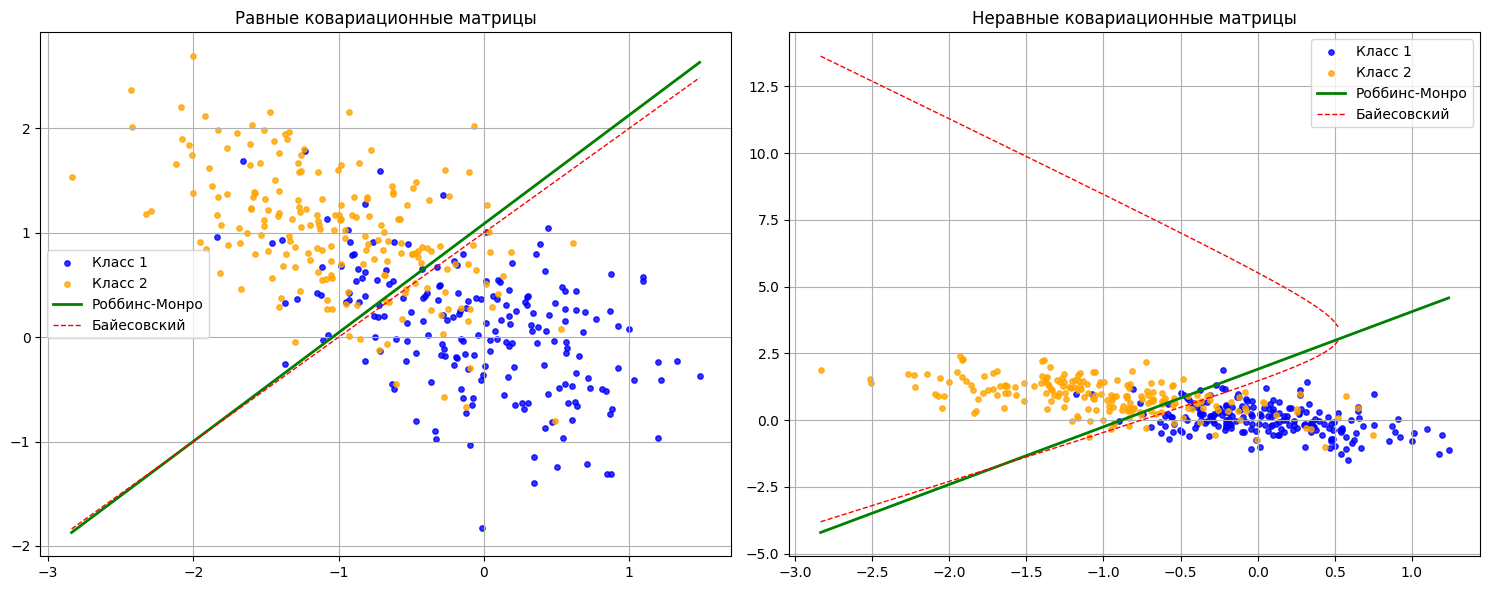


ОШИБКИ КЛАССИФИКАЦИИ:
Равные матрицы - Роббинс-Монро:
Эпохи сходимости: 8
Вероятность ошибки I рода: 0.805
Вероятность ошибки II рода: 0.810
Суммарная ошибка: 1.615

Неравные матрицы - Роббинс-Монро:
Эпохи сходимости: 6
Вероятность ошибки I рода: 0.960
Вероятность ошибки II рода: 0.740
Суммарная ошибка: 1.700


In [201]:
print("=== ПРОЦЕДУРА РОББИНСА-МОНРО ===")

# Для равных ковариационных матриц
print("Для равных ковариационных матриц:")
x_RM1, y_RM1, epoch1 = Robinson_Monroe(X1_samples1, X2_samples1, min_X1_X2_1, max_X1_X2_1, beta=0.7, W=[1, 1, 1], plot=True)

# Для неравных ковариационных матриц
print("\nДля неравных ковариационных матриц:")
x_RM2, y_RM2, epoch2 = Robinson_Monroe(X1_samples2, X2_samples2, min_X1_X2_2, max_X1_X2_2, beta=0.7, W=[1, 1, 1])

# Визуализация результатов
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.scatter(X1_samples1[:,0], X1_samples1[:,1], s=15, label='Класс 1', alpha=0.8, color="blue")
plt.scatter(X2_samples1[:,0], X2_samples1[:,1], s=15, label='Класс 2', alpha=0.8, color="orange")
plt.plot(x_RM1, y_RM1, label='Роббинс-Монро', color='green', linewidth=2)
plt.plot(x_Bayes1, y_Bayes1, label='Байесовский', color='red', linestyle='--', linewidth=1)
plt.legend()
plt.title('Равные ковариационные матрицы')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(X1_samples2[:,0], X1_samples2[:,1], s=15, label='Класс 1', alpha=0.8, color="blue")
plt.scatter(X2_samples2[:,0], X2_samples2[:,1], s=15, label='Класс 2', alpha=0.8, color="orange")
plt.plot(x_RM2, y_RM2, label='Роббинс-Монро', color='green', linewidth=2)
plt.plot(x_Bayes2, y_Bayes2_1, label='Байесовский', color='red', linestyle='--', linewidth=1)
plt.plot(x_Bayes2, y_Bayes2_2, color='red', linestyle='--', linewidth=1)
plt.legend()
plt.title('Неравные ковариационные матрицы')
plt.grid(True)

plt.tight_layout()
plt.show()

# Расчет ошибок
print("\nОШИБКИ КЛАССИФИКАЦИИ:")

# Для равных матриц
a, b, eq = fit_line_from_points(x_RM1, y_RM1)
p0_RM1_exp, p1_RM1_exp = compute_number_errors2(X1_samples1, X2_samples1, a, b)
print("Равные матрицы - Роббинс-Монро:")
print(f"Эпохи сходимости: {epoch1}")
print(f"Вероятность ошибки I рода: {p0_RM1_exp:.3f}")
print(f"Вероятность ошибки II рода: {p1_RM1_exp:.3f}")
print(f"Суммарная ошибка: {p0_RM1_exp + p1_RM1_exp:.3f}")

# Для неравных матриц
a, b, eq = fit_line_from_points(x_RM2, y_RM2)
p0_RM2_exp, p1_RM2_exp = compute_number_errors2(X1_samples2, X2_samples2, a, b)
print("\nНеравные матрицы - Роббинс-Монро:")
print(f"Эпохи сходимости: {epoch2}")
print(f"Вероятность ошибки I рода: {p0_RM2_exp:.3f}")
print(f"Вероятность ошибки II рода: {p1_RM2_exp:.3f}")
print(f"Суммарная ошибка: {p0_RM2_exp + p1_RM2_exp:.3f}")